# Cardiac EDA
Exploratory analysis of the cardiac datasets with pipeline-aligned data stages and consistent comparisons.

## Imports
Load required libraries for data handling, plotting, and lightweight statistics.

In [1]:
from __future__ import annotations
from pathlib import Path
import json
import warnings
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

## Paths and configuration
Define project paths, load pipeline config, and set shared color mappings.

In [2]:
ROOT_DIR = Path.cwd().resolve()
if (ROOT_DIR / "configs").exists() is False:
    ROOT_DIR = ROOT_DIR.parents[0]
DATA_DIR = ROOT_DIR / "data" / "cardiac"
RESULTS_DIR = ROOT_DIR / "results" / "cardiac"
CONFIG_DIR = ROOT_DIR / "configs"

PIPELINE_CFG_PATH = CONFIG_DIR / "pipelines" / "cardiac.yaml"
FEATURE_MAP_PATH = CONFIG_DIR / "domain" / "cardiac_feature_map.yaml"
SCHEMA_PATH = CONFIG_DIR / "schema" / "cardiac.json"

with open(PIPELINE_CFG_PATH, "r") as f:
    pipeline_cfg = yaml.safe_load(f)

with open(FEATURE_MAP_PATH, "r") as f:
    feature_map = yaml.safe_load(f)

with open(SCHEMA_PATH, "r") as f:
    schema_cfg = json.load(f)

EXTERNAL_DIR = ROOT_DIR / pipeline_cfg["paths"]["external_dir"]
RAW_DIR = ROOT_DIR / pipeline_cfg["paths"]["raw_dir"]
PROCESSED_DIR = ROOT_DIR / pipeline_cfg["paths"]["processed_dir"]

DATASETS = schema_cfg.get("cardiac_relevant_datasets", ["cleveland", "kaggle_heart", "cardio70k"])
PRIMARY_DATASETS = ["cleveland", "kaggle_heart"]
TARGET_COL = feature_map["target"]["heart_disease"]["canonical"]
SENSITIVE_COL = feature_map["sensitive"]["sex"]["canonical"]

PALETTE_DATASET = {"cleveland": "#4c72b0", "kaggle_heart": "#55a868", "cardio70k": "#c44e52"}
PALETTE_SEX = {"Female": "#4c72b0", "Male": "#dd8452", "Other": "#7f7f7f"}
PALETTE_TARGET = {0: "#4c72b0", 1: "#c44e52"}

ROOT_DIR, DATA_DIR, RESULTS_DIR

(PosixPath('/home/miguel/Desktop/Dissertacao/Code/FairXAI'),
 PosixPath('/home/miguel/Desktop/Dissertacao/Code/FairXAI/data/cardiac'),
 PosixPath('/home/miguel/Desktop/Dissertacao/Code/FairXAI/results/cardiac'))

## Pipeline overview
Summarize how data moves from external sources to standardized raw and processed splits.

External data is standardized into raw datasets (canonical schema), then preprocessed into train/test splits with scaling and metadata outputs.

Preprocessing steps used in the pipeline: missing-value handling, stratified train/test split, scaling, and per-dataset metadata outputs.

## Load external, raw, and processed datasets
Read each dataset in its lifecycle stages to enable before/after comparisons.

In [3]:
EXTERNAL_FILES = {
    "cleveland": EXTERNAL_DIR / "heart_cleveland_upload.csv",
    "kaggle_heart": EXTERNAL_DIR / "heart.csv",
    "cardio70k": EXTERNAL_DIR / "cardio_train.csv",
}

def load_external():
    return {name: pd.read_csv(path) for name, path in EXTERNAL_FILES.items()}

def load_raw():
    return {name: pd.read_csv(RAW_DIR / f"{name}_standardized.csv") for name in DATASETS}

def load_processed_scaled():
    processed = {}
    for name in DATASETS:
        base = PROCESSED_DIR / name
        train_path = base / f"{name}_train_scaled.csv"
        test_path = base / f"{name}_test_scaled.csv"
        if train_path.exists() and test_path.exists():
            processed[name] = {
                "train": pd.read_csv(train_path),
                "test": pd.read_csv(test_path),
            }
    return processed

external = load_external()
raw = load_raw()
processed = load_processed_scaled()
{k: v.shape for k, v in raw.items()}

{'cleveland': (297, 17), 'kaggle_heart': (918, 15), 'cardio70k': (70000, 13)}

## Data quality and cleaning impact
Compare external vs raw to quantify row drops and missingness.

In [4]:
def summarize_stage(dfs, stage):
    rows = []
    for name, df in dfs.items():
        rows.append({
            "dataset": name,
            "stage": stage,
            "rows": len(df),
            "cols": len(df.columns),
            "missing_cells": int(df.isna().sum().sum()),
            "rows_with_missing": int(df.isna().any(axis=1).sum()),
        })
    return pd.DataFrame(rows)

summary_external = summarize_stage(external, "external")
summary_raw = summarize_stage(raw, "raw")
cleaning_summary = summary_external.merge(summary_raw, on="dataset", suffixes=("_external", "_raw"))
cleaning_summary["rows_removed"] = cleaning_summary["rows_external"] - cleaning_summary["rows_raw"]
cleaning_summary["pct_removed"] = (cleaning_summary["rows_removed"] / cleaning_summary["rows_external"]).round(4)
cleaning_summary[["dataset", "rows_external", "rows_raw", "rows_removed", "pct_removed", "rows_with_missing_external"]]

,dataset,rows_external,rows_raw,rows_removed,pct_removed,rows_with_missing_external
0,cleveland,297,297,0,0.0,0
1,kaggle_heart,918,918,0,0.0,0
2,cardio70k,70000,70000,0,0.0,0


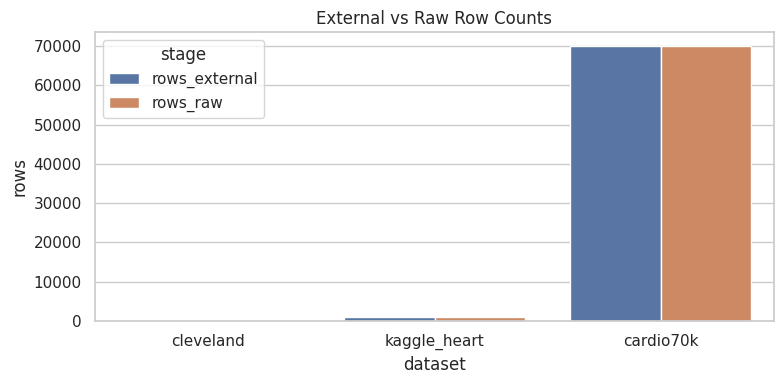

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = cleaning_summary.melt(id_vars="dataset", value_vars=["rows_external", "rows_raw"], var_name="stage", value_name="rows")
sns.barplot(data=plot_df, x="dataset", y="rows", hue="stage", ax=ax)
ax.set_title("External vs Raw Row Counts")
ax.set_ylabel("rows")
plt.tight_layout()

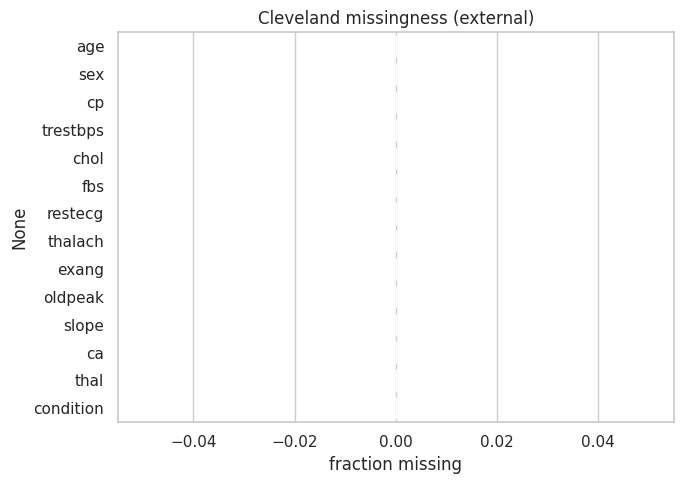

In [6]:
cleveland_external = external.get("cleveland")
if cleveland_external is not None:
    missing = cleveland_external.isna().mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.barplot(x=missing.values, y=missing.index, ax=ax, color=PALETTE_DATASET["cleveland"])
    ax.set_title("Cleveland missingness (external)")
    ax.set_xlabel("fraction missing")
    plt.tight_layout()

## Feature schema comparison (canonical mapping)
Use the YAML feature map to compare canonical features rather than raw column names.

In [7]:
def canonical_features_for_columns(columns: list[str]) -> set[str]:
    canonical = set()
    for group in ("sensitive", "common", "target"):
        for _, info in feature_map.get(group, {}).items():
            aliases = info.get("aliases", [])
            if any(alias in columns for alias in aliases):
                canonical.add(info.get("canonical"))
    return canonical

canonical_by_dataset = {name: canonical_features_for_columns(df.columns) for name, df in raw.items()}
shared_canonical = set.intersection(*canonical_by_dataset.values())
unique_canonical = {name: sorted(list(canonical_by_dataset[name] - shared_canonical)) for name in canonical_by_dataset}

print("Shared canonical features:", len(shared_canonical))
for name, feats in unique_canonical.items():
    print(f"{name} unique canonical features: {feats}")

Shared canonical features: 1
cleveland unique canonical features: ['ca', 'chol', 'cp', 'exang', 'fbs', 'oldpeak', 'restecg', 'slope', 'thal', 'thalach', 'trestbps']
kaggle_heart unique canonical features: ['chol', 'cp', 'exang', 'fbs', 'oldpeak', 'restecg', 'slope', 'thalach', 'trestbps']
cardio70k unique canonical features: []


Note: Cleveland is a subset inside the Kaggle Heart compilation; Cardio70k follows a different schema.

## Sensitive attribute analysis: age
Compare age distributions with unit awareness across datasets.

In [8]:
def age_to_years(series: pd.Series) -> pd.Series:
    if series.dropna().max() > 130:
        return series / 365.25
    return series

age_units = []
for name, df in raw.items():
    raw_age = df["age_raw"]
    unit = "days" if raw_age.dropna().max() > 130 else "years"
    age_units.append({"dataset": name, "age_unit": unit})
pd.DataFrame(age_units)

,dataset,age_unit
0,cleveland,years
1,kaggle_heart,years
2,cardio70k,years


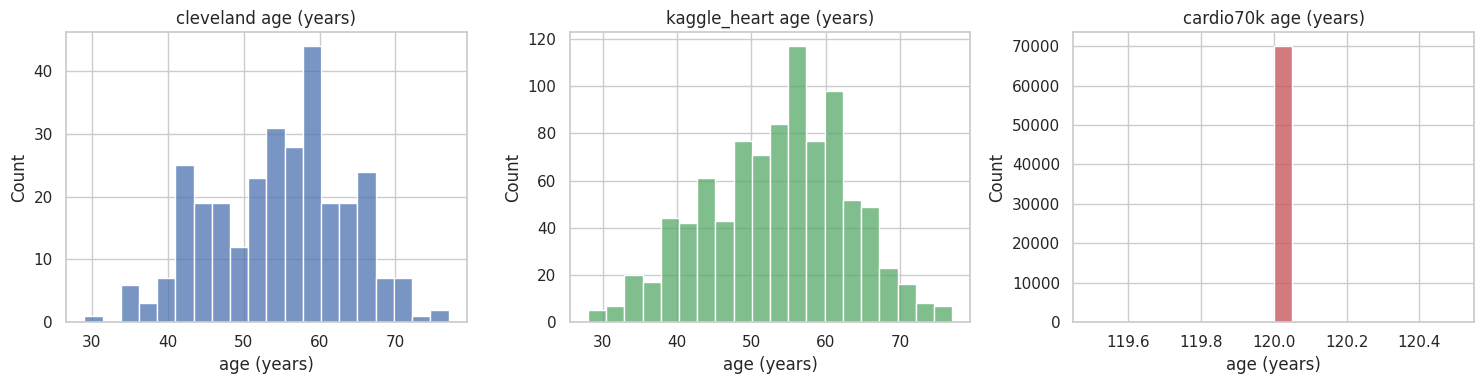

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, name in enumerate(DATASETS):
    df = raw[name]
    age_years = age_to_years(df["age_raw"])
    sns.histplot(age_years, bins=20, ax=axes[idx], color=PALETTE_DATASET.get(name, "#4c72b0"))
    axes[idx].set_title(f"{name} age (years)")
    axes[idx].set_xlabel("age (years)")
plt.tight_layout()

### Age groups (raw standardized)
Compare standardized age_group distributions for each dataset.

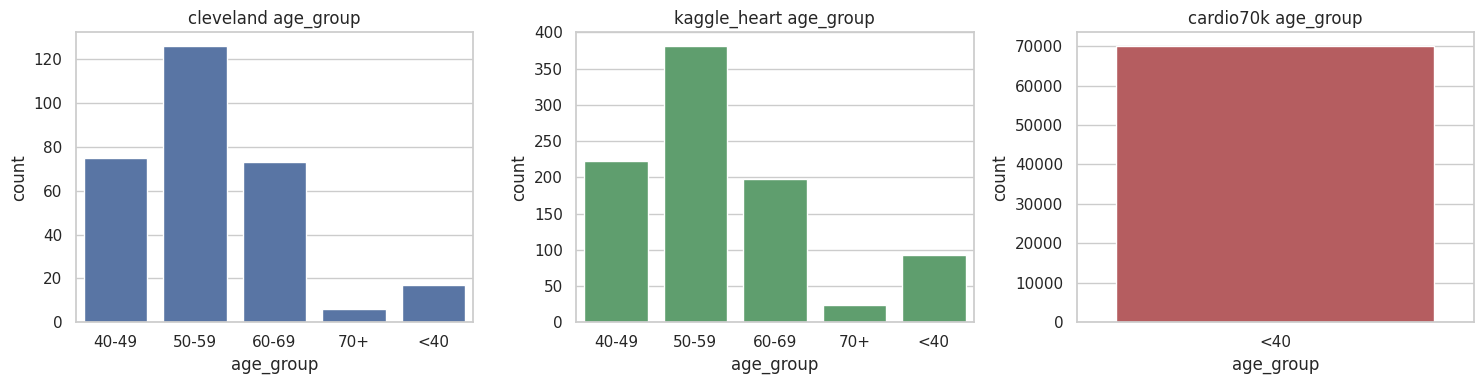

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, name in enumerate(DATASETS):
    df = raw[name]
    if "age_group" not in df.columns:
        axes[idx].set_title(f"{name} (missing age_group)")
        continue
    counts = df["age_group"].value_counts().sort_index()
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=axes[idx], color=PALETTE_DATASET.get(name, "#4c72b0"))
    axes[idx].set_title(f"{name} age_group")
    axes[idx].set_xlabel("age_group")
    axes[idx].set_ylabel("count")
plt.tight_layout()

,dataset,min,max,mean,median,std
0,cleveland,29,77,54.542088,56.0,9.049736
1,kaggle_heart,28,77,53.510893,54.0,9.432617
2,cardio70k,120,120,120.000000,120.0,0.000000


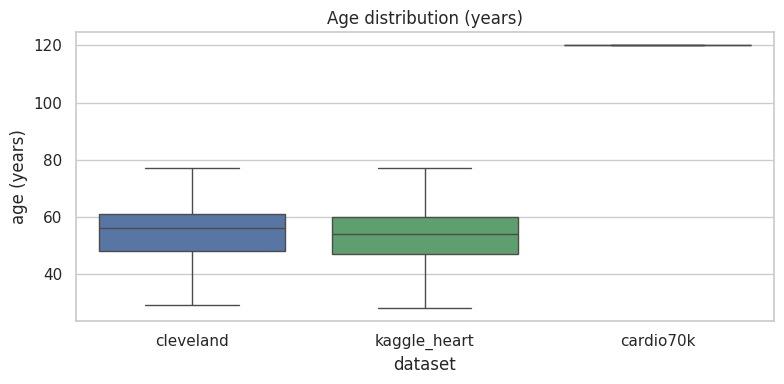

In [11]:
age_stats = []
age_plot_rows = []
for name, df in raw.items():
    age_years = age_to_years(df["age_raw"])
    age_stats.append({
        "dataset": name,
        "min": age_years.min(),
        "max": age_years.max(),
        "mean": age_years.mean(),
        "median": age_years.median(),
        "std": age_years.std(),
    })
    age_plot_rows.append(pd.DataFrame({"dataset": name, "age_years": age_years}))

age_stats_df = pd.DataFrame(age_stats)
age_plot = pd.concat(age_plot_rows, ignore_index=True)
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=age_plot, x="dataset", y="age_years", ax=ax, palette=PALETTE_DATASET)
ax.set_title("Age distribution (years)")
ax.set_xlabel("dataset")
ax.set_ylabel("age (years)")
plt.tight_layout()
display(age_stats_df)

## Sensitive attribute analysis: sex
Compare sex encoding and distribution across datasets.

In [12]:
sex_tables = []
for name, df in raw.items():
    if "sex_extended" in df.columns:
        counts = df["sex_extended"].value_counts(dropna=False)
        total = counts.sum()
        for label, value in counts.items():
            sex_tables.append({
                "dataset": name,
                "sex": label,
                "count": int(value),
                "pct": round(value / total, 4),
            })
sex_df = pd.DataFrame(sex_tables)
display(sex_df)

,dataset,sex,count,pct
0,cleveland,Male,201,0.6768
1,cleveland,Female,96,0.3232
2,kaggle_heart,Male,725,0.7898
3,kaggle_heart,Female,193,0.2102


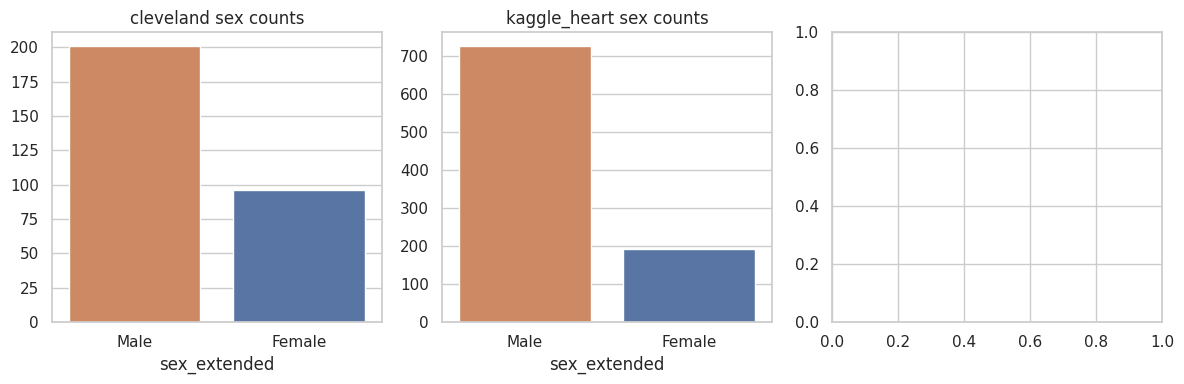

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for idx, name in enumerate(DATASETS):
    df = raw[name]
    if "sex_extended" not in df.columns:
        continue
    counts = df["sex_extended"].value_counts(dropna=False)
    bar_colors = [PALETTE_SEX.get(str(x), "#7f7f7f") for x in counts.index]
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=axes[idx], palette=bar_colors)
    axes[idx].set_title(f"{name} sex counts")
plt.tight_layout()

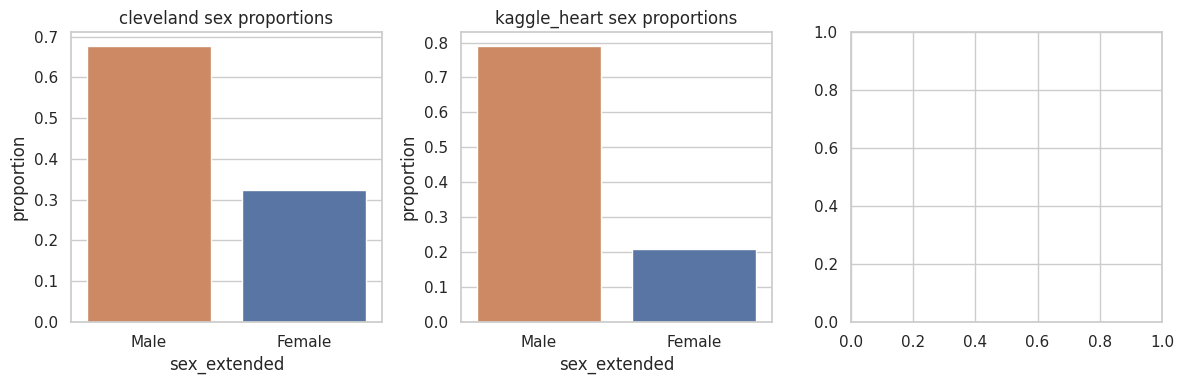

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for idx, name in enumerate(DATASETS):
    df = raw[name]
    if "sex_extended" not in df.columns:
        continue
    counts = df["sex_extended"].value_counts(dropna=False)
    prop = counts / counts.sum()
    sns.barplot(x=prop.index.astype(str), y=prop.values, ax=axes[idx], palette=[PALETTE_SEX.get(str(x), "#7f7f7f") for x in prop.index])
    axes[idx].set_title(f"{name} sex proportions")
    axes[idx].set_ylabel("proportion")
plt.tight_layout()

## Intersectional view: age group x sex
Compare age-group composition by sex within each dataset.

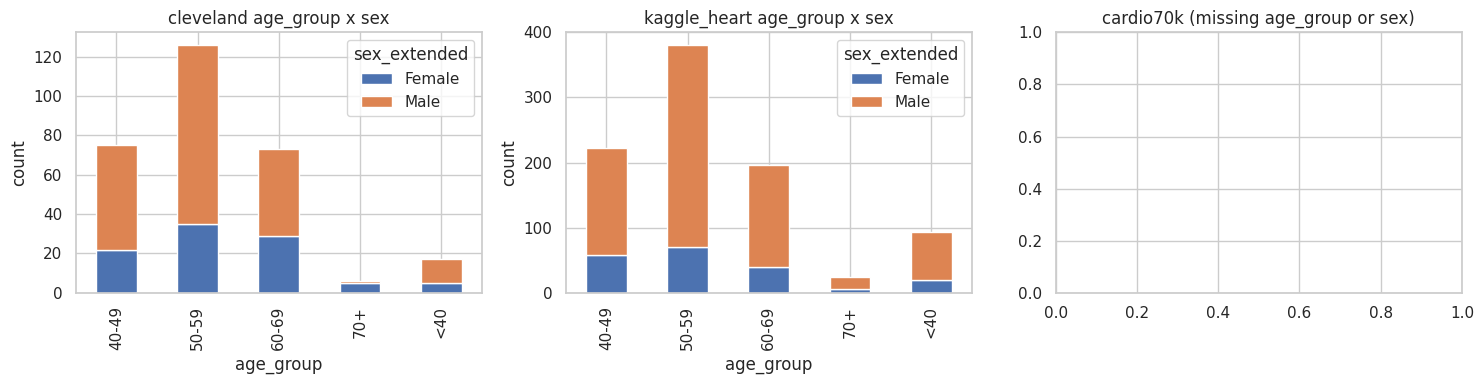

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, name in enumerate(DATASETS):
    df = raw[name]
    if "age_group" not in df.columns or "sex_extended" not in df.columns:
        axes[idx].set_title(f"{name} (missing age_group or sex)")
        continue
    grouped = df.groupby(["age_group", "sex_extended"]).size().reset_index(name="count")
    pivoted = grouped.pivot(index="age_group", columns="sex_extended", values="count").fillna(0)
    pivoted.plot(kind="bar", stacked=True, ax=axes[idx], color=[PALETTE_SEX.get(c, "#7f7f7f") for c in pivoted.columns])
    axes[idx].set_title(f"{name} age_group x sex")
    axes[idx].set_xlabel("age_group")
    axes[idx].set_ylabel("count")
plt.tight_layout()

## Target variable overview
Show heart disease prevalence overall and by sensitive attributes.

In [16]:
target_rows = []
for name, df in raw.items():
    if TARGET_COL in df.columns:
        target_rows.append({"dataset": name, "prevalence": float(df[TARGET_COL].mean())})
pd.DataFrame(target_rows)

,dataset,prevalence
0,cleveland,0.461279
1,kaggle_heart,0.553377
2,cardio70k,0.499700


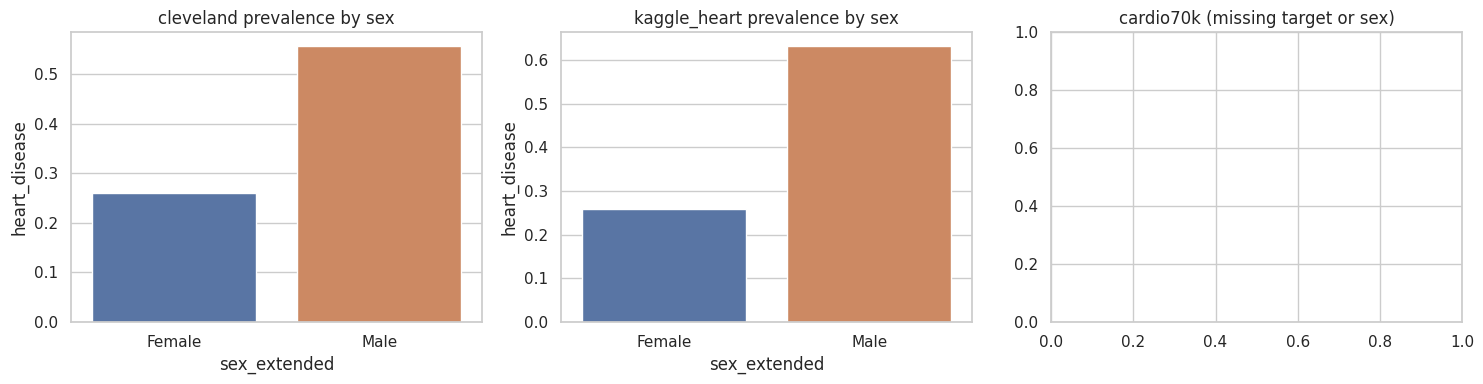

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, name in enumerate(DATASETS):
    df = raw[name]
    if TARGET_COL not in df.columns or "sex_extended" not in df.columns:
        axes[idx].set_title(f"{name} (missing target or sex)")
        continue
    grouped = df.groupby("sex_extended")[TARGET_COL].mean().reset_index()
    sns.barplot(data=grouped, x="sex_extended", y=TARGET_COL, ax=axes[idx], palette=PALETTE_SEX)
    axes[idx].set_title(f"{name} prevalence by sex")
plt.tight_layout()

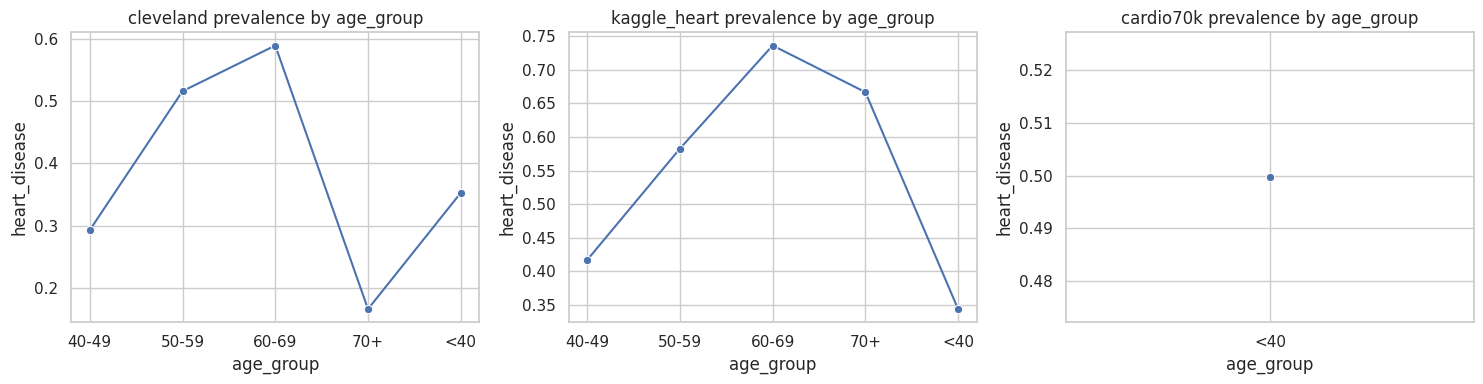

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, name in enumerate(DATASETS):
    df = raw[name]
    if TARGET_COL not in df.columns or "age_group" not in df.columns:
        axes[idx].set_title(f"{name} (missing target or age_group)")
        continue
    grouped = df.groupby("age_group")[TARGET_COL].mean().reset_index()
    sns.lineplot(data=grouped, x="age_group", y=TARGET_COL, ax=axes[idx], marker="o")
    axes[idx].set_title(f"{name} prevalence by age_group")
    axes[idx].set_xlabel("age_group")
plt.tight_layout()

## Clinical feature distributions (Cleveland vs Kaggle)
Compare shared clinical features for the two primary datasets.

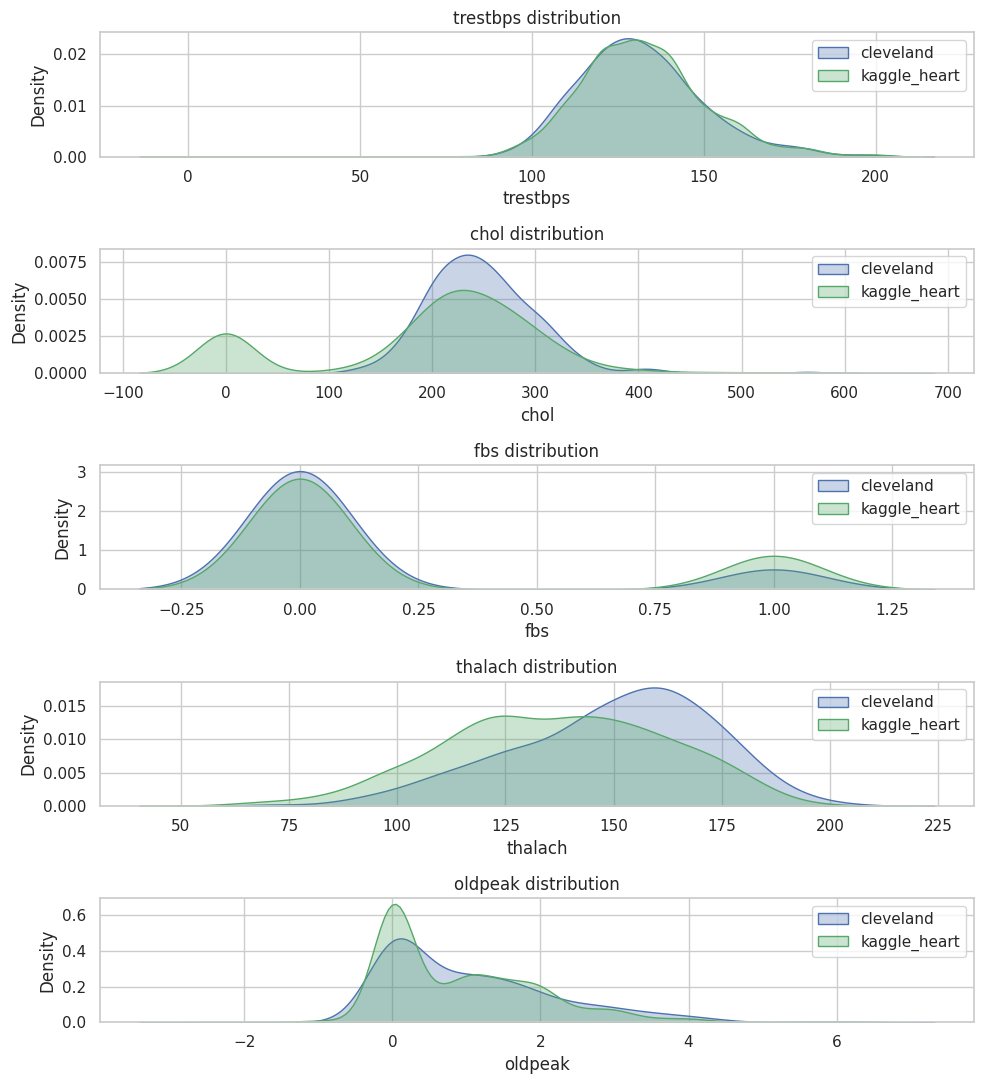

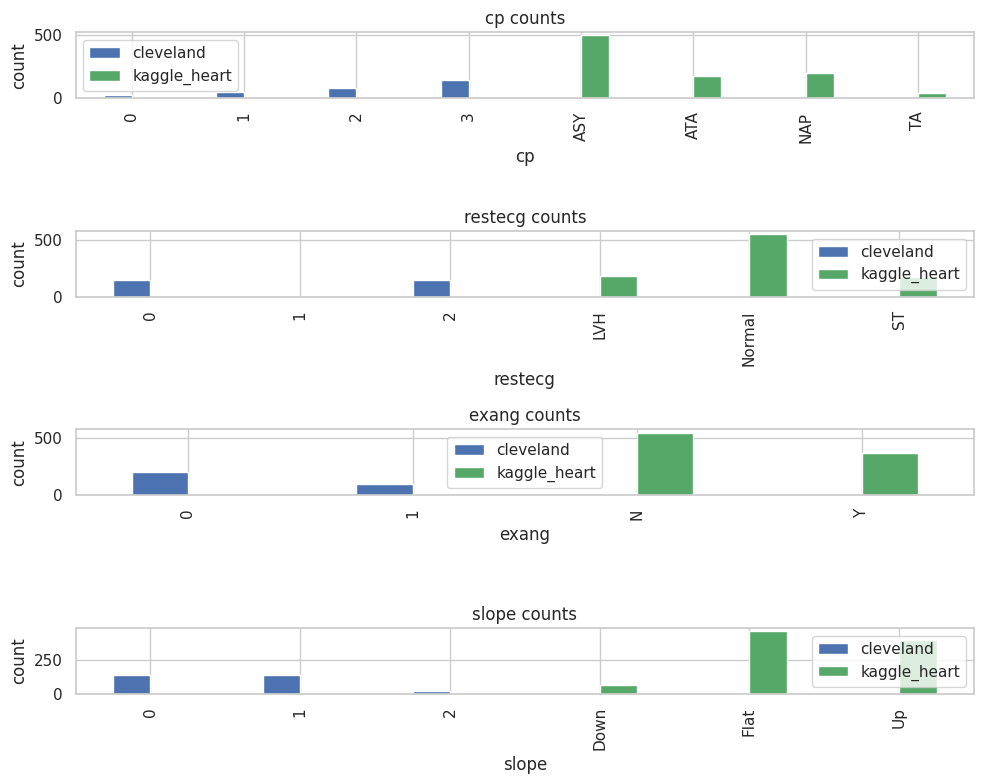

In [29]:
shared_common = [info["canonical"] for info in feature_map.get("common", {}).values()]
cleveland_df = raw["cleveland"]
kaggle_df = raw["kaggle_heart"]

plot_features = [f for f in shared_common if f in cleveland_df.columns and f in kaggle_df.columns]

def numeric_series(df: pd.DataFrame, feature: str) -> pd.Series:
    return pd.to_numeric(df[feature], errors="coerce")

numeric_features = []
categorical_features = []
for feature in plot_features:
    clev_num = numeric_series(cleveland_df, feature)
    kag_num = numeric_series(kaggle_df, feature)
    if clev_num.notna().any() and kag_num.notna().any():
        numeric_features.append(feature)
    else:
        categorical_features.append(feature)

if numeric_features:
    fig, axes = plt.subplots(len(numeric_features), 1, figsize=(10, max(4, len(numeric_features) * 2.2)))
    if len(numeric_features) == 1:
        axes = [axes]
    for idx, feature in enumerate(numeric_features):
        sns.kdeplot(numeric_series(cleveland_df, feature).dropna(), ax=axes[idx], label="cleveland", color=PALETTE_DATASET["cleveland"], fill=True, alpha=0.3)
        sns.kdeplot(numeric_series(kaggle_df, feature).dropna(), ax=axes[idx], label="kaggle_heart", color=PALETTE_DATASET["kaggle_heart"], fill=True, alpha=0.3)
        axes[idx].set_title(f"{feature} distribution")
        axes[idx].legend(loc="best")
    plt.tight_layout()
else:
    print("No shared numeric features found for Cleveland vs Kaggle.")

if categorical_features:
    fig, axes = plt.subplots(len(categorical_features), 1, figsize=(10, max(4, len(categorical_features) * 2.0)))
    if len(categorical_features) == 1:
        axes = [axes]
    for idx, feature in enumerate(categorical_features):
        clev_counts = cleveland_df[feature].astype(str).value_counts()
        kag_counts = kaggle_df[feature].astype(str).value_counts()
        counts_df = pd.DataFrame({"cleveland": clev_counts, "kaggle_heart": kag_counts}).fillna(0).sort_index()
        counts_df.plot(kind="bar", ax=axes[idx], color=[PALETTE_DATASET["cleveland"], PALETTE_DATASET["kaggle_heart"]])
        axes[idx].set_title(f"{feature} counts")
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel("count")
    plt.tight_layout()

In [30]:
stat_rows = []
for feature in numeric_features:
    clev_vals = numeric_series(cleveland_df, feature).dropna()
    kag_vals = numeric_series(kaggle_df, feature).dropna()
    if clev_vals.nunique() > 1 and kag_vals.nunique() > 1:
        stat = ks_2samp(clev_vals, kag_vals)
        stat_rows.append({"feature": feature, "ks_stat": stat.statistic, "p_value": stat.pvalue})
pd.DataFrame(stat_rows)

,feature,ks_stat,p_value
0,trestbps,0.035948,9.219938e-01
1,chol,0.206774,6.938954e-09
2,fbs,0.088334,5.624560e-02
3,thalach,0.254704,2.698904e-13
4,oldpeak,0.091800,4.236559e-02


## Correlation structure (Cleveland vs Kaggle)
Review correlation patterns for shared clinical features.

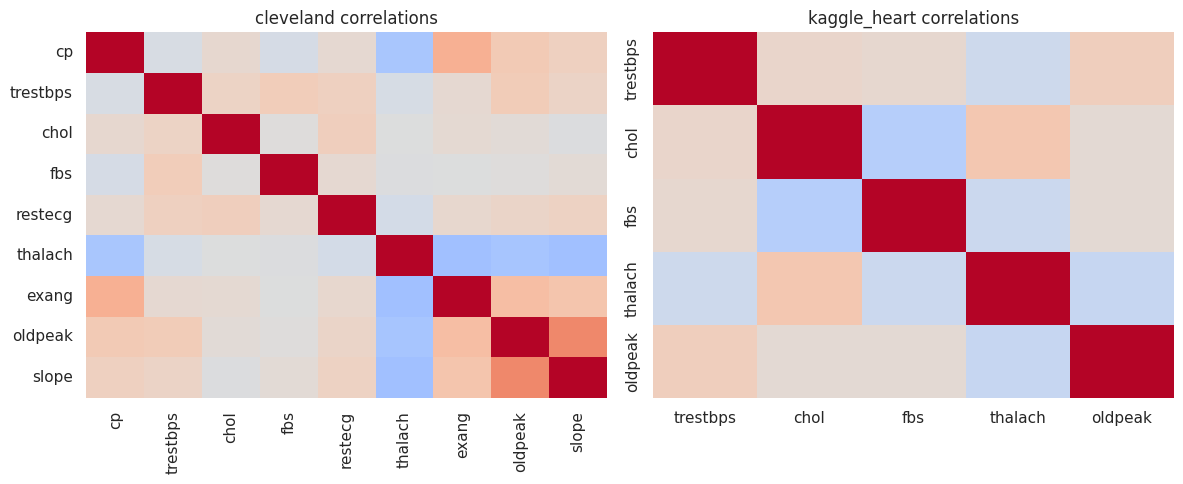

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, (name, df) in enumerate([("cleveland", cleveland_df), ("kaggle_heart", kaggle_df)]):
    numeric = df[plot_features].select_dtypes(include=[np.number])
    corr = numeric.corr(numeric_only=True)
    sns.heatmap(corr, ax=axes[idx], cmap="coolwarm", center=0, cbar=False)
    axes[idx].set_title(f"{name} correlations")
plt.tight_layout()

## Clustering and similarity view (raw)
Explore potential latent groups beyond age/sex using a simple PCA + KMeans view.

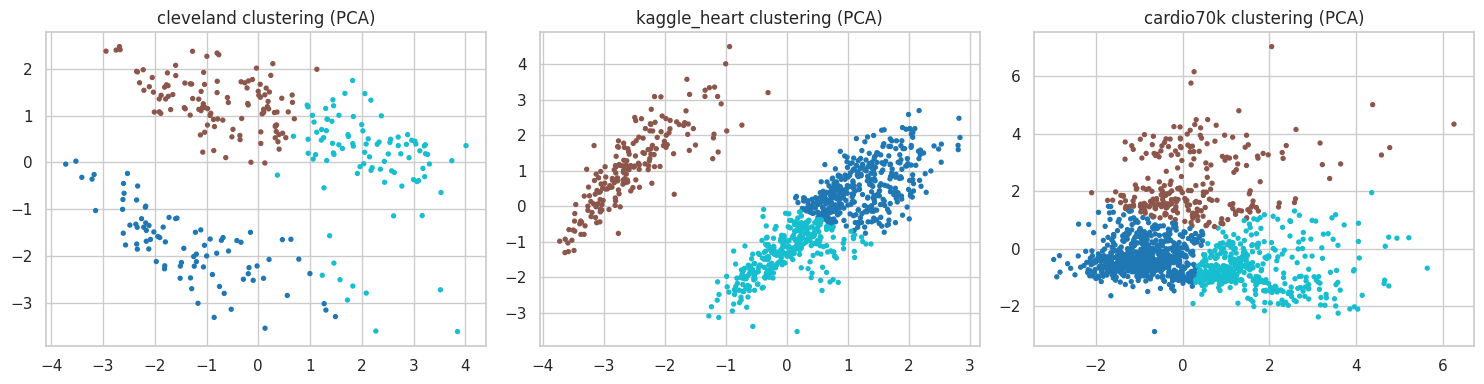

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, name in enumerate(DATASETS):
    df = raw[name]
    numeric = df.select_dtypes(include=[np.number]).drop(columns=[TARGET_COL], errors="ignore")
    numeric = numeric.dropna(axis=0)
    if numeric.empty:
        axes[idx].set_title(f"{name} clustering (no data)")
        continue
    sample = numeric.sample(n=min(1500, len(numeric)), random_state=42)
    scaled = StandardScaler().fit_transform(sample)
    pca = PCA(n_components=2, random_state=42)
    emb = pca.fit_transform(scaled)
    kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
    clusters = kmeans.fit_predict(emb)
    axes[idx].scatter(emb[:, 0], emb[:, 1], c=clusters, s=8, cmap="tab10")
    axes[idx].set_title(f"{name} clustering (PCA)")
plt.tight_layout()

## Cardio70k-specific features
Focus on features unique to the 70k dataset and their distributions.

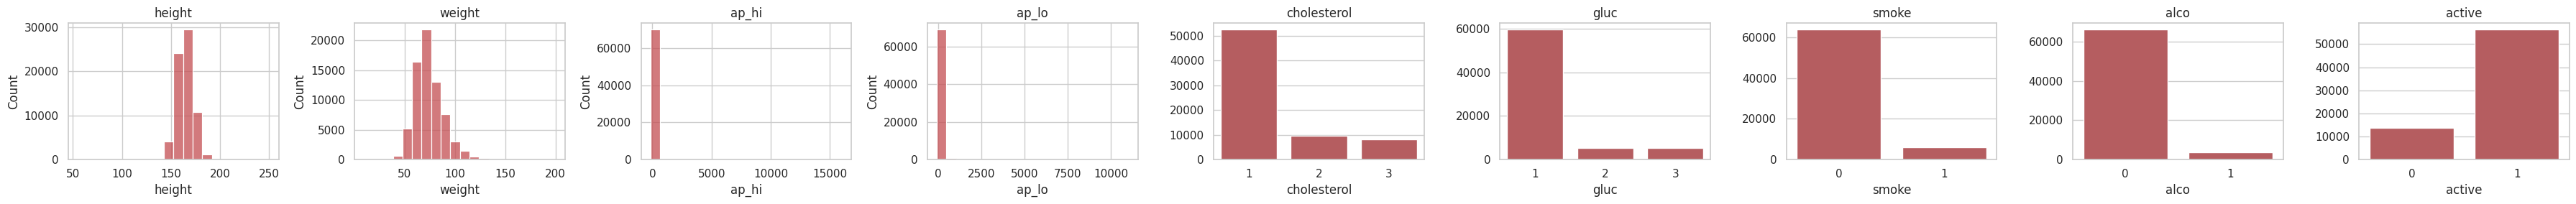

In [23]:
cardio_df = raw.get("cardio70k")
if cardio_df is not None:
    cardio_unique = list(feature_map.get("dataset_specific", {}).get("cardio70k", {}).keys())
    cardio_unique = [f for f in cardio_unique if f in cardio_df.columns]
    if cardio_unique:
        fig, axes = plt.subplots(1, len(cardio_unique), figsize=(4 * len(cardio_unique), 3))
        if len(cardio_unique) == 1:
            axes = [axes]
        for idx, feature in enumerate(cardio_unique):
            if cardio_df[feature].nunique() <= 5:
                counts = cardio_df[feature].value_counts().sort_index()
                sns.barplot(x=counts.index.astype(str), y=counts.values, ax=axes[idx], color=PALETTE_DATASET["cardio70k"])
            else:
                sns.histplot(cardio_df[feature], bins=20, ax=axes[idx], color=PALETTE_DATASET["cardio70k"])
            axes[idx].set_title(feature)
        plt.tight_layout()
    else:
        print("No cardio70k-specific features found in raw data.")

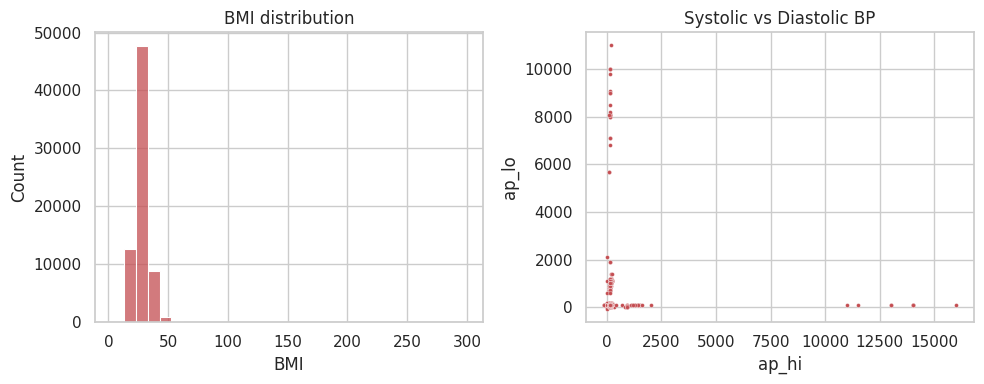

In [24]:
if cardio_df is not None and {"height", "weight"}.issubset(cardio_df.columns):
    bmi = cardio_df["weight"] / (cardio_df["height"] / 100) ** 2
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(bmi, bins=30, ax=axes[0], color=PALETTE_DATASET["cardio70k"])
    axes[0].set_title("BMI distribution")
    axes[0].set_xlabel("BMI")
    if {"ap_hi", "ap_lo"}.issubset(cardio_df.columns):
        sns.scatterplot(x=cardio_df["ap_hi"], y=cardio_df["ap_lo"], ax=axes[1], s=8, color=PALETTE_DATASET["cardio70k"])
        axes[1].set_title("Systolic vs Diastolic BP")
        axes[1].set_xlabel("ap_hi")
        axes[1].set_ylabel("ap_lo")
    plt.tight_layout()

## Processed data quality
Summarize train/test sizes and preprocessing metadata outputs.

In [25]:
processed_rows = []
for name, splits in processed.items():
    processed_rows.append({
        "dataset": name,
        "train_rows": len(splits["train"]),
        "test_rows": len(splits["test"]),
        "cols": len(splits["train"].columns),
    })
pd.DataFrame(processed_rows)

,dataset,train_rows,test_rows,cols
0,cleveland,206,89,16
1,kaggle_heart,641,276,14
2,cardio70k,49000,21000,12


In [26]:
metadata_files = list(PROCESSED_DIR.glob("**/preprocessing_metadata.json"))
summary_files = list(PROCESSED_DIR.glob("**/preprocessing_summary.json"))

metadata_rows = []
for path in metadata_files:
    with open(path, "r") as f:
        meta = json.load(f)
    for entry in meta.get("datasets", []):
        entry["source_path"] = str(path)
        metadata_rows.append(entry)

summary_rows = []
for path in summary_files:
    with open(path, "r") as f:
        summ = json.load(f)
    for entry in summ.get("summary", []):
        entry["source_path"] = str(path)
        summary_rows.append(entry)

display(pd.DataFrame(metadata_rows).head())
display(pd.DataFrame(summary_rows).head())

""


""


## Baseline and fairness outputs (latest run)
Load baseline and fairness summaries from the most recent run if available.

In [27]:
def resolve_latest_run(results_dir: Path) -> Path | None:
    latest_txt = results_dir / "latest_run.txt"
    if latest_txt.exists():
        run_id = latest_txt.read_text().strip()
        run_dir = results_dir / "runs" / run_id
        if run_dir.exists():
            return run_dir
    return None

latest_run = resolve_latest_run(RESULTS_DIR)
latest_run

PosixPath('/home/miguel/Desktop/Dissertacao/Code/FairXAI/results/cardiac/runs/run_20260204_110832_949_18027_e467e0')

In [28]:
if latest_run is None:
    print("No latest run found under results/cardiac/runs.")
else:
    baseline_dir = latest_run / "baseline"
    baseline_jsons = list(baseline_dir.glob("**/*baseline_metrics*.json"))
    print(f"Found {len(baseline_jsons)} baseline metric files")
    if baseline_jsons:
        rows = []
        for path in baseline_jsons:
            with open(path, "r") as f:
                data = json.load(f)
            dataset = data.get("dataset") or path.stem
            metrics = data.get("metrics", {})
            rows.append({"dataset": dataset, **metrics})
        display(pd.DataFrame(rows))
    fairness_dir = baseline_dir / "fairness"
    fairness_csvs = list(fairness_dir.glob("*_fairness_summary.csv"))
    if fairness_csvs:
        summaries = []
        for path in fairness_csvs:
            df = pd.read_csv(path)
            df["dataset"] = path.stem.replace("_fairness_summary", "")
            summaries.append(df)
        display(pd.concat(summaries, ignore_index=True))
    print("Note: cardio70k baseline may be missing until baseline training supports it.")

Found 0 baseline metric files


,sensitive_attribute,metric,is_fair,max_difference,tpr_max_difference,fpr_max_difference,split,dataset
0,age_group_cat,demographic_parity,False,0.607843,NaN,NaN,train,cleveland
1,age_group_cat,equalized_odds,False,NaN,1.000000,0.238095,train,cleveland
2,age_group_cat,equal_opportunity,False,1.000000,NaN,NaN,train,cleveland
3,age_group_cat,predictive_parity,False,1.000000,NaN,NaN,train,cleveland
4,sex_cat,demographic_parity,False,0.329870,NaN,NaN,train,cleveland
5,sex_cat,equalized_odds,False,NaN,0.184295,0.081290,train,cleveland
6,sex_cat,equal_opportunity,False,0.184295,NaN,NaN,train,cleveland
7,sex_cat,predictive_parity,False,0.138462,NaN,NaN,train,cleveland
8,age_group_cat,demographic_parity,False,0.590909,NaN,NaN,test,cleveland
9,age_group_cat,equalized_odds,False,NaN,0.833333,0.333333,test,cleveland


Note: cardio70k baseline may be missing until baseline training supports it.


## Key observations (to be filled)
Leave space for conclusions after reviewing the plots and tables.

- 
- 
- 